## Setup & Data Loading

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from ydata_profiling import ProfileReport
%matplotlib inline

In [9]:
# Load data using project root path

PROJECT_ROOT = Path().resolve().parent.parent
data_path = PROJECT_ROOT / "bank-deposit-prediction" / "data" / "raw" / "bank.csv"

df = pd.read_csv(data_path)

# Preview
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


## Dataset Overview

In [14]:
# Shape of dataset
print("Shape of dataset:", df.shape)

# Column names, Data types and non-null counts
df.info()

Shape of dataset: (11162, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [18]:
bank_profile = ProfileReport(df, title="Bank Data Profile", explorative=True)
bank_profile.to_file("Bank_profile_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 17/17 [00:00<00:00, 105634.32it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

## Missing Values 

In [16]:
missing_values = df.isnull().sum()

print("Missing values per column:\n")
print(missing_values[missing_values > 0])

Missing values per column:

Series([], dtype: int64)


In [32]:
# Checking 'unknown' values in categorical features

categorical_cols = df.select_dtypes(include='object').columns

print("Columns with 'unknown' values:")

for col in categorical_cols:
    count = (df[col] == 'unknown').sum()
    if count > 0:
        percentage = (count / len(df)) * 100
        print(f"{col}: {count} ({percentage:.2f}%)")

Columns with 'unknown' values:
job: 70 (0.63%)
education: 497 (4.45%)
contact: 2346 (21.02%)
poutcome: 8326 (74.59%)


## Duplicate Records

In [38]:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


## Outlier Analysis

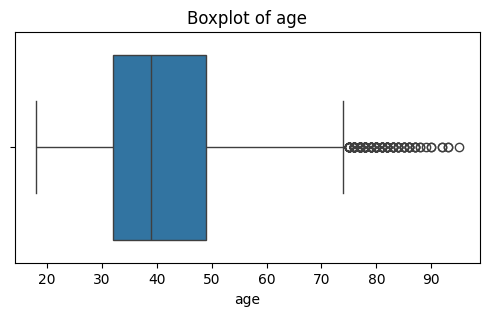

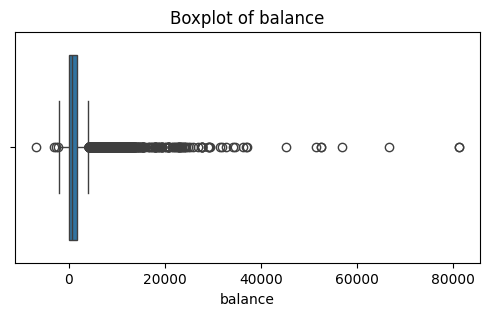

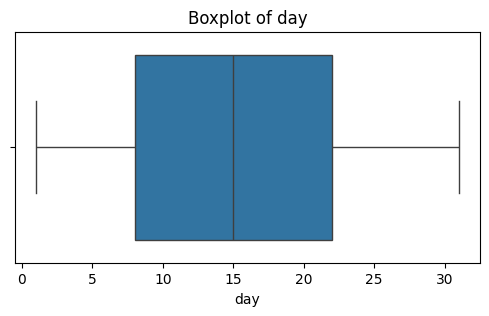

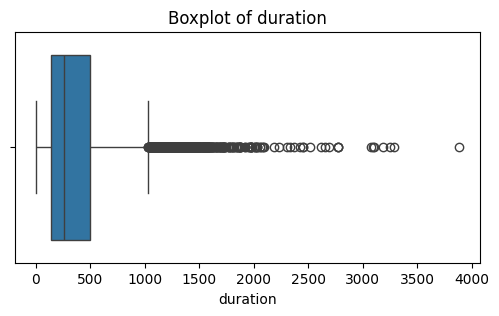

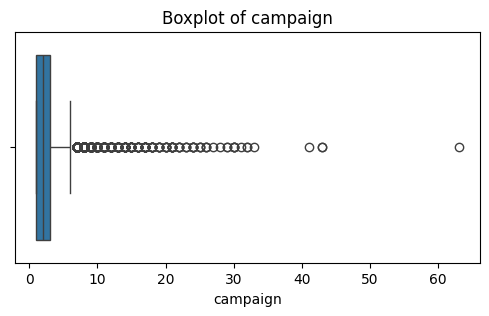

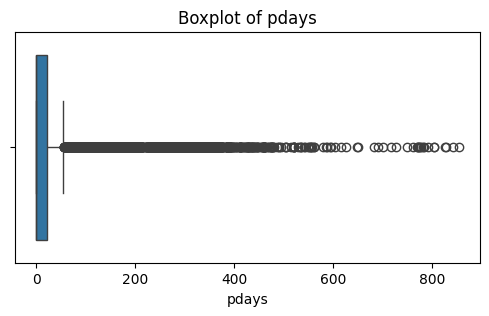

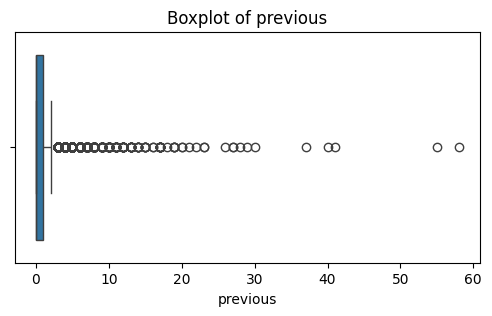

In [39]:
numerical_cols = df.select_dtypes(include=['int64']).columns

for col in numerical_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

## Target Variable Analysis

deposit
no     5873
yes    5289
Name: count, dtype: int64

Percentage:
 deposit
no     0.52616
yes    0.47384
Name: proportion, dtype: float64


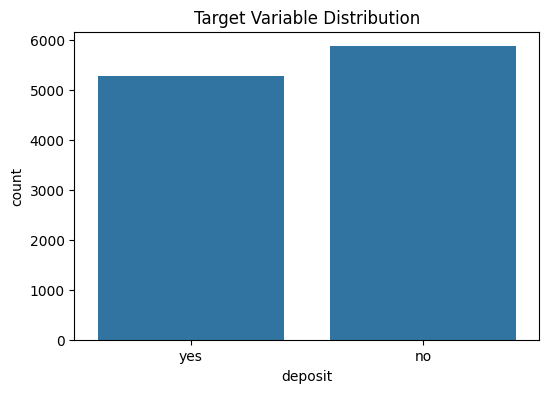

In [35]:
# Count
target_counts = df['deposit'].value_counts()
print(target_counts)

# Percentage
target_ratio = df['deposit'].value_counts(normalize=True)
print("\nPercentage:\n", target_ratio)

# Plot
plt.figure(figsize=(6,4))
sns.countplot(x='deposit', data=df)
plt.title("Target Variable Distribution")
plt.show()

## Numerical Features Analysis

In [25]:

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("Numerical Columns:\n", numerical_cols)

# Summary statistics
df[numerical_cols].describe()

Numerical Columns:
 Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')


,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


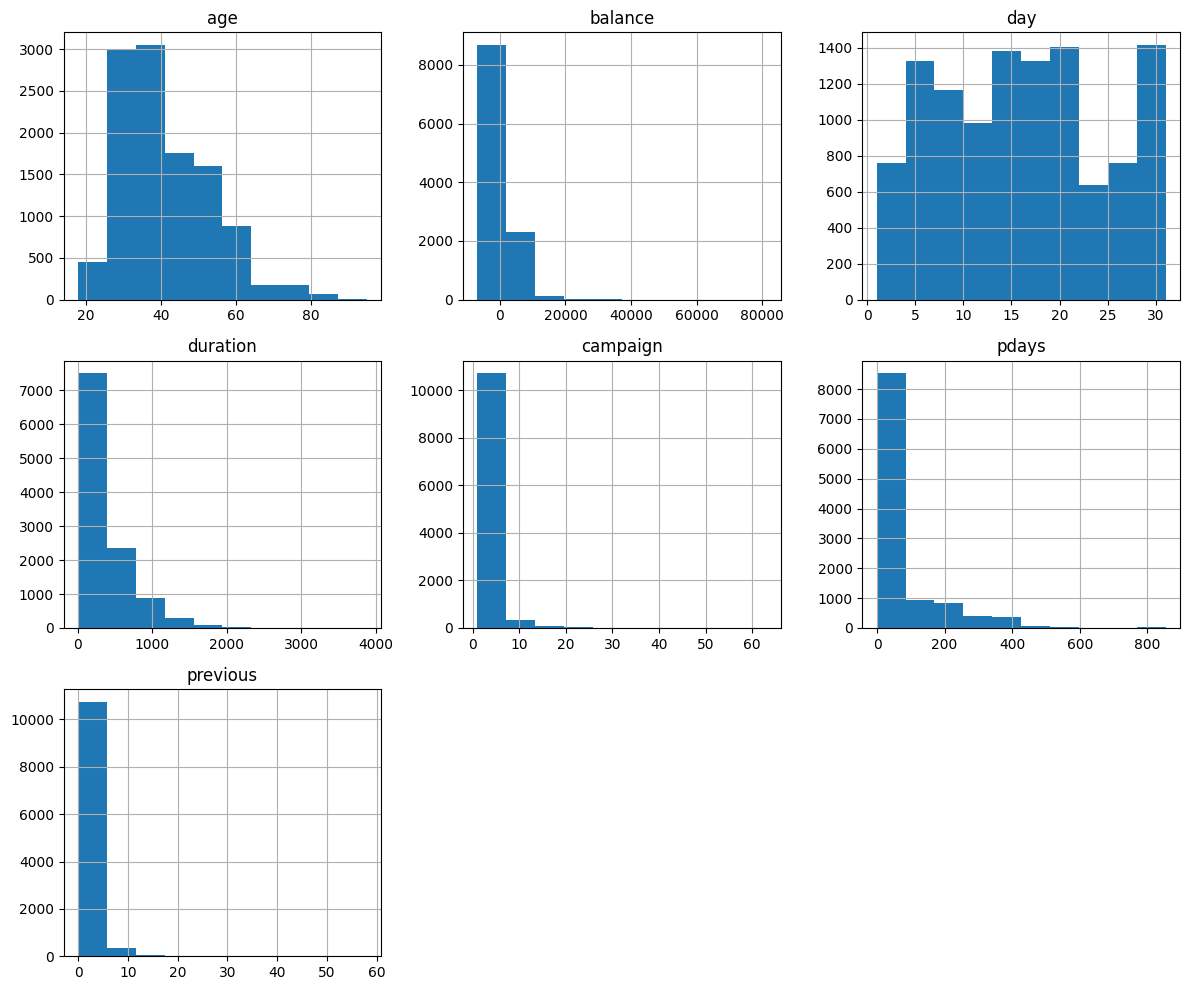

In [36]:
df[numerical_cols].hist(figsize=(12,10))
plt.tight_layout()
plt.show()

## Categorical Features Analysis

In [28]:
categorical_cols = df.select_dtypes(include='object').columns
categorical_cols = categorical_cols.drop('deposit')  # exclude target

print("Categorical Columns:\n", categorical_cols)

Categorical Columns:
 Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object')


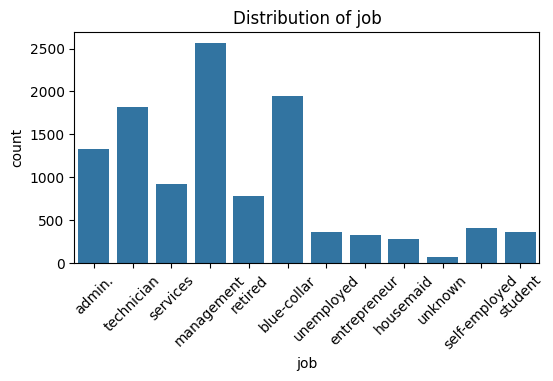

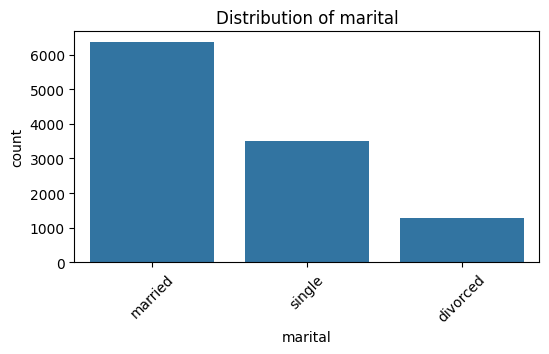

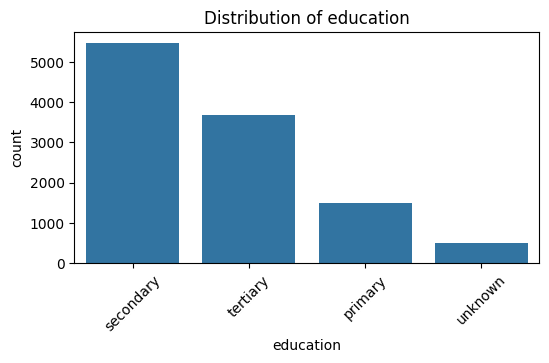

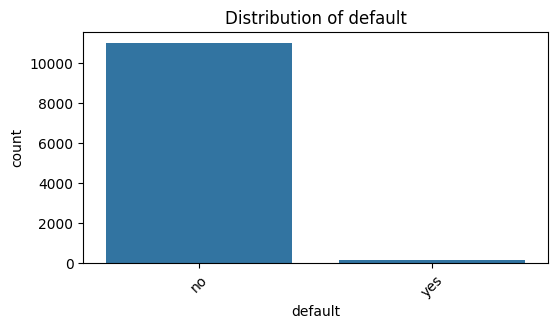

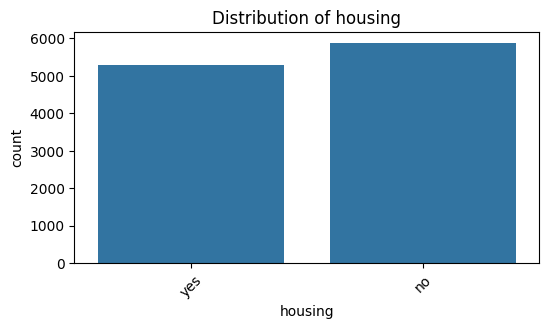

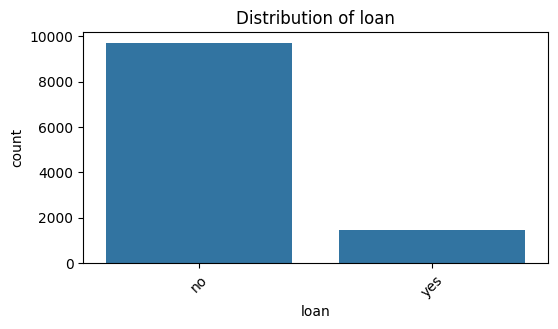

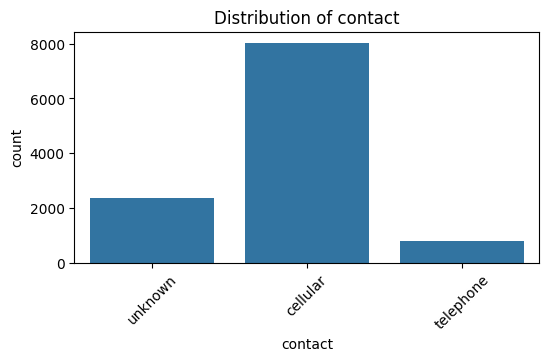

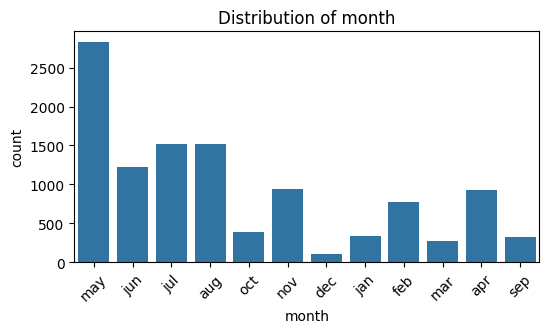

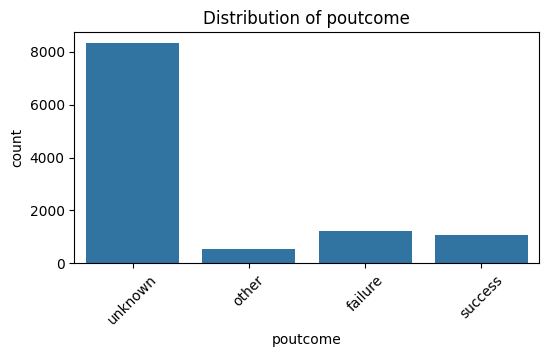

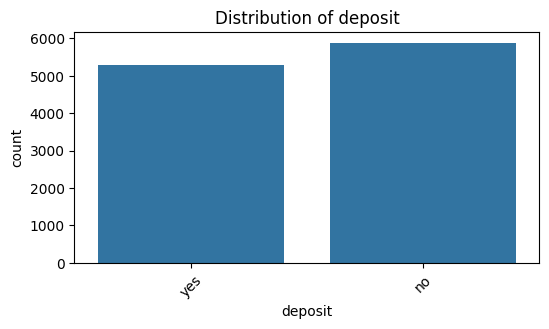

In [37]:
for col in categorical_cols:
    plt.figure(figsize=(6,3))
    sns.countplot(x=col, data=df)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.show()

## Findings:

- The dataset contains 11,162 observations and 17 features
- Features include: 7 numerical variables, 10 categorical variables (6 categorical, 4 boolean)

- No missing values were detected in the dataset. Although no NaN values exist, some categorical variables contain "unknown" values, which act as hidden missing values. The feature poutcome contains 74.6% unknown values, although heavily dominated by "unknown", the feature contains valuable information for clients with previous campaign history. So all unknown will be treated as category
- No duplicate records were found in the dataset.
- Outlier analysis revealed that several numerical features, such as balance, campaign, pdays, and previous, contain extreme values and exhibit skewed distributions. However, since tree-based models are robust to outliers, these values were retained. Instead of removing them, appropriate scaling techniques will be applied during preprocessing.

- Dataset is fairly balanced, Slight skew toward “no”, but NOT heavily imbalanced 

- Several numerical features such as balance, campaign, pdays, and previous are highly skewed and contain outliers, which may affect model performance and require scaling or transformation.

- The feature duration represents the length of the current phone call and is recorded after the interaction, making it unavailable at prediction time and leading to data leakage.The feature duration will be removed before modeling

- Historical Features: pdays indicates the number of days since the client was last contacted (from previous campaigns), previous represents number of contacts performed before this campaign, poutcome: Outcome of the previous marketing campaign. These features provide valuable historical context and are available before prediction, making them important predictors.

- The feature campaign represents the number of contacts made with the client during the current campaign. Unlike duration, it does not directly reveal the outcome and can provide useful information about customer engagement, and is therefore retained for modeling.

- The feature default is highly imbalanced (almost all values are “no”), indicating low variance, it will be removed, as it is unlikely to contribute meaningful predictive power

## Preprocessing Strategy

- Remove leakage and low-variance features (duration, default)
- Encode categorical variables using one-hot encoding
- Scale numerical features to handle skewness and improve model performance
- Transform pdays to account for special values (-1)